Final analytical notebook. Run after Notebook 02 and save in Google Colab.


# 03 | Recursive LightGBM Forecasting and Evaluation

Notebook 02 produced the seasonal-naive and Holt-Winters results. Here I test one global LightGBM model using the same 30 series, four historical test periods and 28-day horizon.

"Global" means that one model learns from all 30 category-store series. The forecast is recursive: day 1 is predicted from observed history, and later days use earlier predictions when the required actual demand is not yet available.

I use the following selection rule, which was set before comparing the final results:

1. LightGBM must have lower overall RMSSE than both baselines.
2. It must beat seasonal-naive on at least 16 of the 30 series.


## 1. Set up the model

The LightGBM hyperparameters were fixed before the four outer-fold results were inspected. A fresh model is fitted at each forecast origin using only the training data available at that origin. No tuning is performed on the four test periods.


In [1]:
from pathlib import Path
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/MSc_Dissertation_Forecasting_Final")
except ImportError:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    PROJECT_ROOT = next(
        (path for path in candidates if (path / "src").is_dir()),
        Path.cwd().resolve(),
    )

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        f"Project source folder not found under {PROJECT_ROOT}."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.project_paths import ProjectPaths

PATHS = ProjectPaths(PROJECT_ROOT)
PATHS.ensure_output_directories()


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import FOLDS, LIGHTGBM_PARAMS, RANDOM_STATE
from src.evaluation import build_metric_table
from src.lightgbm_model import (
    NUMERIC_FEATURES,
    build_training_frame,
    prepare_calendar,
    recursive_lightgbm_forecasts,
    verify_post_origin_masking,
)
from src.model_selection import (
    build_paired_robustness_table,
    evaluate_model_selection,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

parameter_table = pd.DataFrame(
    [
        {"hyperparameter": key, "value": value}
        for key, value in LIGHTGBM_PARAMS.items()
    ]
)
display(parameter_table)
print(f"Random state: {RANDOM_STATE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,hyperparameter,value
0,objective,regression
1,n_estimators,500
2,learning_rate,0.0300
3,num_leaves,31
4,max_depth,-1
5,min_child_samples,50
6,subsample,0.9000
7,subsample_freq,1
8,colsample_bytree,0.9000
9,reg_lambda,1.0000


Random state: 42


### Model choice and fixed configuration

LightGBM can represent nonlinear patterns and interactions while pooling information across the 30 related series. Category, store and state identifiers allow the global model to retain series-level differences.

The fixed configuration uses squared-error regression, 500 trees, a learning rate of 0.03 and conservative tree-size, subsampling and L2-regularisation controls. It evaluates one reproducible specification rather than a tuned performance ceiling.


## 2. Choose information available at forecast time

For any forecast date, demand features are built only from earlier dates:

- demand lags: 1, 7, 14, and 28 days;
- rolling means: previous 7 and 28 days, explicitly shifted by one day;
- known calendar fields: weekday, month, event types, and state-specific SNAP indicators;
- static identifiers: category, store, and state.

I exclude price from the main model. Price is recorded at item-store-week level, while the target is category-store-day demand. Future price availability is also less clear. Including it would require additional assumptions about aggregation and timing that are outside the final scope.


In [2]:
panel = pd.read_csv(PATHS.processed / "m5_category_store_panel.csv", parse_dates=["date"])
calendar = prepare_calendar(PATHS.m5_file("calendar.csv"))

feature_register = pd.DataFrame(
    [
        {
            "feature": "lag_1",
            "type": "Demand history",
            "available_at_origin": True,
            "purpose": "Immediate demand persistence",
        },
        {
            "feature": "lag_7",
            "type": "Demand history",
            "available_at_origin": True,
            "purpose": "Weekly recurrence",
        },
        {
            "feature": "lag_14",
            "type": "Demand history",
            "available_at_origin": True,
            "purpose": "Two-week recurrence",
        },
        {
            "feature": "lag_28",
            "type": "Demand history",
            "available_at_origin": True,
            "purpose": "Four-week recurrence",
        },
        {
            "feature": "rolling_mean_7",
            "type": "Demand history",
            "available_at_origin": True,
            "purpose": "Recent demand level",
        },
        {
            "feature": "rolling_mean_28",
            "type": "Demand history",
            "available_at_origin": True,
            "purpose": "Monthly demand level",
        },
        {
            "feature": "weekday/month",
            "type": "Calendar",
            "available_at_origin": True,
            "purpose": "Calendar seasonality",
        },
        {
            "feature": "event_type_1/2",
            "type": "Calendar",
            "available_at_origin": True,
            "purpose": "Known event context",
        },
        {
            "feature": "SNAP",
            "type": "Calendar",
            "available_at_origin": True,
            "purpose": "Known state programme day",
        },
        {
            "feature": "category/store/state",
            "type": "Identifier",
            "available_at_origin": True,
            "purpose": "Cross-series differences",
        },
    ]
)
display(feature_register)

training_example = build_training_frame(panel, calendar, FOLDS[0].origin_day)
print(f"F1 training rows after lag construction: {len(training_example):,}")
display(training_example[["series_id", "day_number", "actual", *NUMERIC_FEATURES]].tail(8))


,feature,type,available_at_origin,purpose
0,lag_1,Demand history,True,Immediate demand persistence
1,lag_7,Demand history,True,Weekly recurrence
2,lag_14,Demand history,True,Two-week recurrence
3,lag_28,Demand history,True,Four-week recurrence
4,rolling_mean_7,Demand history,True,Recent demand level
5,rolling_mean_28,Demand history,True,Monthly demand level
6,weekday/month,Calendar,True,Calendar seasonality
7,event_type_1/2,Calendar,True,Known event context
8,SNAP,Calendar,True,Known state programme day
9,category/store/state,Identifier,True,Cross-series differences


F1 training rows after lag construction: 54,030


,series_id,day_number,actual,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,snap
54022,HOUSEHOLD_WI_3,1822,930,959.0000,728.0000,752.0000,777.0000,679.7143,727.0000,0.0000
54023,HOUSEHOLD_WI_3,1823,636,930.0000,620.0000,540.0000,392.0000,708.5714,732.4643,0.0000
54024,HOUSEHOLD_WI_3,1824,529,636.0000,598.0000,457.0000,648.0000,710.8571,741.1786,0.0000
54025,HOUSEHOLD_WI_3,1825,588,529.0000,540.0000,552.0000,678.0000,701.0000,736.9286,0.0000
54026,HOUSEHOLD_WI_3,1826,549,588.0000,529.0000,729.0000,"1,110.0000",707.8571,733.7143,0.0000
54027,HOUSEHOLD_WI_3,1827,853,549.0000,784.0000,909.0000,669.0000,710.7143,713.6786,0.0000
54028,HOUSEHOLD_WI_3,1828,1143,853.0000,959.0000,"1,034.0000","1,037.0000",720.5714,720.2500,0.0000
54029,HOUSEHOLD_WI_3,1829,1019,"1,143.0000",930.0000,728.0000,914.0000,746.8571,724.0357,0.0000


### Worked check: where one feature row comes from

The next cell rebuilds the demand-history features for one row directly from the original series. This verifies that every lag points backwards and that both rolling averages end on the previous day.


In [3]:
feature_check_series = "FOODS_CA_1"
feature_check_day = FOLDS[0].origin_day
feature_history = (
    panel.query("series_id == @feature_check_series and day_number <= @feature_check_day")
    .sort_values("day_number")
    .set_index("day_number")["actual"]
)
feature_row = training_example.query(
    "series_id == @feature_check_series and day_number == @feature_check_day"
).iloc[0]

manual_features = {
    "lag_1": float(feature_history.loc[feature_check_day - 1]),
    "lag_7": float(feature_history.loc[feature_check_day - 7]),
    "lag_14": float(feature_history.loc[feature_check_day - 14]),
    "lag_28": float(feature_history.loc[feature_check_day - 28]),
    "rolling_mean_7": float(
        feature_history.loc[feature_check_day - 7 : feature_check_day - 1].mean()
    ),
    "rolling_mean_28": float(
        feature_history.loc[feature_check_day - 28 : feature_check_day - 1].mean()
    ),
}
feature_check = pd.DataFrame(
    {
        "feature": list(manual_features),
        "manual_value": list(manual_features.values()),
        "training_frame_value": [float(feature_row[name]) for name in manual_features],
    }
)
feature_check["absolute_difference"] = (
    feature_check["manual_value"] - feature_check["training_frame_value"]
).abs()

assert feature_check["absolute_difference"].lt(1e-10).all()
display(feature_check)
print("All worked lag and rolling calculations match the training frame.")


,feature,manual_value,training_frame_value,absolute_difference
0,lag_1,"3,481.0000","3,481.0000",0.0000
1,lag_7,"3,440.0000","3,440.0000",0.0000
2,lag_14,"3,534.0000","3,534.0000",0.0000
3,lag_28,"3,261.0000","3,261.0000",0.0000
4,rolling_mean_7,"2,540.4286","2,540.4286",0.0000
5,rolling_mean_28,"2,711.6429","2,711.6429",0.0000


All worked lag and rolling calculations match the training frame.


The first 28 observations of each series do not have enough earlier history for `lag_28` and the 28-day rolling mean, so those training rows are removed. This is caused by feature construction, not by missing source data.

The rolling averages are shifted by one day. Without the shift, the model would use the value it is trying to predict, which would be leakage.

## 3. Produce the 28-day forecasts

For each fold, the procedure is:

1. Build training features only through the origin day.
2. Fit one global LightGBM model.
3. Construct features for forecast day 1 from observed history.
4. Predict day 1 and append that prediction to a temporary history.
5. Construct day 2 features using observed history plus the day 1 prediction.
6. Repeat until all 28 days are forecast.
7. Join actual test demand only after all predictions exist.

This matches the information that would be available in a real 28-day forecast. It also means that an early error can affect later days.


In [4]:
lightgbm_forecasts, feature_importance = recursive_lightgbm_forecasts(panel, calendar)

expected_rows = 30 * 4 * 28
assert len(lightgbm_forecasts) == expected_rows
assert lightgbm_forecasts["forecast"].notna().all()
assert lightgbm_forecasts["forecast"].ge(0).all()
assert lightgbm_forecasts.duplicated(["fold_id", "series_id", "forecast_day"]).sum() == 0

print(f"Recursive LightGBM forecasts generated: {len(lightgbm_forecasts):,}")
display(lightgbm_forecasts.head(10))


Recursive LightGBM forecasts generated: 3,360


,model,fold_id,origin_day,origin_date,series_id,category,store,state,forecast_day,forecast_date,horizon_day,horizon_band,forecast,actual,error,absolute_error,squared_error
0,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_CA_1,FOODS,CA_1,CA,1830,2016-02-01,1,D01-D07,"2,924.0636",2606,-318.0636,318.0636,"101,164.4471"
1,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_CA_2,FOODS,CA_2,CA,1830,2016-02-01,1,D01-D07,"2,675.6179",2169,-506.6179,506.6179,"256,661.6835"
2,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_CA_3,FOODS,CA_3,CA,1830,2016-02-01,1,D01-D07,"4,302.1427",3979,-323.1427,323.1427,"104,421.1775"
3,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_CA_4,FOODS,CA_4,CA,1830,2016-02-01,1,D01-D07,"1,744.0386",1747,2.9614,2.9614,8.7697
4,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_TX_1,FOODS,TX_1,TX,1830,2016-02-01,1,D01-D07,"1,891.1703",2021,129.8297,129.8297,"16,855.7468"
5,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_TX_2,FOODS,TX_2,TX,1830,2016-02-01,1,D01-D07,"2,587.9473",2783,195.0527,195.0527,"38,045.5411"
6,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_TX_3,FOODS,TX_3,TX,1830,2016-02-01,1,D01-D07,"2,639.2523",2794,154.7477,154.7477,"23,946.8507"
7,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_WI_1,FOODS,WI_1,WI,1830,2016-02-01,1,D01-D07,"2,132.1104",2619,486.8896,486.8896,"237,061.4948"
8,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_WI_2,FOODS,WI_2,WI,1830,2016-02-01,1,D01-D07,"2,596.2821",3398,801.7179,801.7179,"642,751.5535"
9,global_lightgbm_recursive,F1,1829,2016-01-31,FOODS_WI_3,FOODS,WI_3,WI,1830,2016-02-01,1,D01-D07,"2,105.5521",2574,468.4479,468.4479,"219,443.4104"


### Worked trace: why the model is recursive

For the first forecast day, `lag_1` is the last observed demand value. From the second day onward, `lag_1` is the model's preceding prediction because the real future value would not be known. The short trace below shows this change for one category-store series.


In [5]:
trace_fold = FOLDS[0]
trace_series = "FOODS_CA_1"
trace_forecasts = (
    lightgbm_forecasts.query(
        "fold_id == @trace_fold.fold_id and series_id == @trace_series"
    )
    .sort_values("horizon_day")
    .head(10)
)
trace_history = (
    panel.query("series_id == @trace_series and day_number <= @trace_fold.origin_day")
    .sort_values("day_number")["actual"]
    .astype(float)
    .tolist()
)
trace_rows = []
for row in trace_forecasts.itertuples(index=False):
    trace_rows.append(
        {
            "horizon_day": row.horizon_day,
            "forecast_day": row.forecast_day,
            "lag_1_value_available_to_model": trace_history[-1],
            "lag_1_source": (
                "Observed history"
                if row.horizon_day == 1
                else "Earlier model forecast"
            ),
            "forecast_produced": row.forecast,
        }
    )
    trace_history.append(float(row.forecast))

recursive_trace = pd.DataFrame(trace_rows)
assert (
    recursive_trace.loc[1, "lag_1_value_available_to_model"]
    == recursive_trace.loc[0, "forecast_produced"]
)
display(recursive_trace)


,horizon_day,forecast_day,lag_1_value_available_to_model,lag_1_source,forecast_produced
0,1,1830,"3,910.0000",Observed history,"2,924.0636"
1,2,1831,"2,924.0636",Earlier model forecast,"2,541.3963"
2,3,1832,"2,541.3963",Earlier model forecast,"2,547.9116"
3,4,1833,"2,547.9116",Earlier model forecast,"2,648.0456"
4,5,1834,"2,648.0456",Earlier model forecast,"3,000.6896"
5,6,1835,"3,000.6896",Earlier model forecast,"4,075.7917"
6,7,1836,"4,075.7917",Earlier model forecast,"3,812.2383"
7,8,1837,"3,812.2383",Earlier model forecast,"2,961.9359"
8,9,1838,"2,961.9359",Earlier model forecast,"2,798.8122"
9,10,1839,"2,798.8122",Earlier model forecast,"2,791.7569"


## 4. Test the post-origin masking control

For each forecast origin, I replace every later actual-demand value with missing data and rerun the standard feature-construction and recursive-forecasting procedure. Previously calculated demand features are not reused.

If the forecasts changed, this would indicate that post-origin demand influenced the implemented pipeline. Unchanged forecasts provide evidence supporting the leakage controls, but do not prove that every possible source of leakage has been excluded.


In [6]:
leakage_results = verify_post_origin_masking(panel, calendar, lightgbm_forecasts)
display(leakage_results)

assert leakage_results["passed"].all()
assert leakage_results["n_predictions"].eq(30 * 28).all()
assert leakage_results["maximum_absolute_difference"].eq(0).all()
print("Post-origin masking test passed at all four origins.")


,fold_id,origin_day,n_predictions,maximum_absolute_difference,passed
0,F1,1829,840,0.0000,True
1,F2,1857,840,0.0000,True
2,F3,1885,840,0.0000,True
3,F4,1913,840,0.0000,True


Post-origin masking test passed at all four origins.


The test covers all four origins and 840 predictions per fold. The acceptance rule is an absolute tolerance of 1 × 10⁻¹⁰ with zero relative tolerance. A maximum difference of 0.0 in every fold is evidence supporting the implemented leakage controls rather than proof that every possible leakage source has been excluded.

## 5. Compare all three models

All three models are evaluated over the same 3,360 forecasts per model: 30 series multiplied by four folds multiplied by 28 days. RMSSE scales are calculated only from each fold's training history. Overall RMSSE is the arithmetic mean of 120 series-fold RMSSE values, while overall WAPE pools absolute error and actual demand across the 3,360 predictions for each model.


In [7]:
baseline_forecasts = pd.read_csv(
    PATHS.powerbi / "fact_forecasts_baselines.csv",
    parse_dates=["origin_date", "forecast_date"],
)
rmsse_scales = pd.read_csv(PATHS.metrics / "rmsse_scales.csv")
all_forecasts = pd.concat([baseline_forecasts, lightgbm_forecasts], ignore_index=True)
all_metrics = build_metric_table(all_forecasts, rmsse_scales)

model_labels = {
    "seasonal_naive_7": "Seasonal naive",
    "holt_winters_add_damped_7": "Holt-Winters",
    "global_lightgbm_recursive": "Global LightGBM",
}
overall = all_metrics.query("scope == 'overall'")[
    ["model", "n_forecasts", "rmsse", "wape", "mae", "rmse"]
].copy()
overall["model_name"] = overall["model"].map(model_labels)
overall["wape_percent"] = overall["wape"] * 100
overall = overall.sort_values("rmsse")
display(overall[["model_name", "n_forecasts", "rmsse", "wape_percent", "mae", "rmse"]])


,model_name,n_forecasts,rmsse,wape_percent,mae,rmse
384,Global LightGBM,3360,0.6528,8.4580,120.0006,197.4598
385,Holt-Winters,3360,0.7300,10.7837,152.9978,289.4703
386,Seasonal naive,3360,0.8865,12.8298,182.0277,327.3745


### Overall result

LightGBM has the lowest RMSSE, WAPE, MAE and RMSE. Its WAPE is approximately 8.46%, compared with 10.78% for Holt-Winters and 12.83% for seasonal-naive.

I also check folds, horizon bands and individual series because one overall score can hide weaker areas.


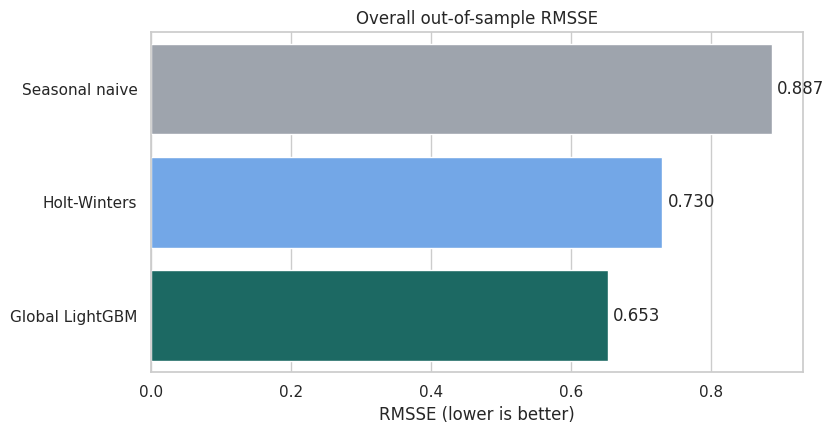

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot_overall = overall.sort_values("rmsse", ascending=False)
sns.barplot(data=plot_overall, x="rmsse", y="model_name", hue="model_name", legend=False,
            palette=["#9CA3AF", "#60A5FA", "#0F766E"], ax=ax)
ax.set(title="Overall out-of-sample RMSSE", xlabel="RMSSE (lower is better)", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4)
fig.tight_layout()
display(fig)
plt.close(fig)


model_name,Seasonal naive,Holt-Winters,Global LightGBM
fold_id,,,
F1,0.9306,0.7270,0.6445
F2,0.8720,0.7483,0.6864
F3,0.9206,0.7087,0.6114
F4,0.8229,0.7359,0.6688


model_name,Seasonal naive,Holt-Winters,Global LightGBM
horizon_band,,,
D01-D07,0.8493,0.7342,0.6513
D08-D14,0.8854,0.7011,0.5760
D15-D21,0.8875,0.7047,0.6289
D22-D28,0.7614,0.6119,0.6269


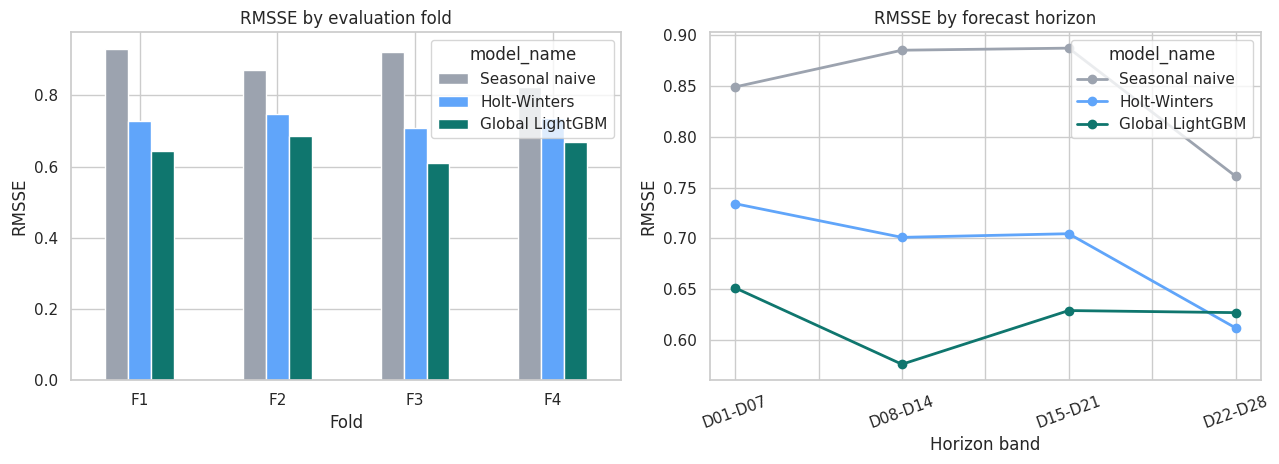

In [9]:
fold_results = (
    all_metrics.query("scope == 'fold'")
    .assign(model_name=lambda frame: frame["model"].map(model_labels))
    .pivot(index="fold_id", columns="model_name", values="rmsse")
    .reindex(columns=["Seasonal naive", "Holt-Winters", "Global LightGBM"])
)
horizon_results = (
    all_metrics.query("scope == 'horizon_band'")
    .assign(model_name=lambda frame: frame["model"].map(model_labels))
    .pivot(index="horizon_band", columns="model_name", values="rmsse")
    .reindex(["D01-D07", "D08-D14", "D15-D21", "D22-D28"])
    .reindex(columns=["Seasonal naive", "Holt-Winters", "Global LightGBM"])
)
display(fold_results)
display(horizon_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fold_results.plot(kind="bar", ax=axes[0], color=["#9CA3AF", "#60A5FA", "#0F766E"])
axes[0].set(title="RMSSE by evaluation fold", xlabel="Fold", ylabel="RMSSE")
axes[0].tick_params(axis="x", rotation=0)
horizon_results.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[1],
    color=["#9CA3AF", "#60A5FA", "#0F766E"],
)
axes[1].set(title="RMSSE by forecast horizon", xlabel="Horizon band", ylabel="RMSSE")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
display(fig)
plt.close(fig)


LightGBM performs best in the first three seven-day bands. Holt-Winters is marginally better in days 22–28. Recursive LightGBM does use earlier predictions as later inputs, so error transmission is a plausible explanation; however, the band-level results do not establish progressive error accumulation.

For this reason, the dashboard reports accuracy by horizon rather than presenting only the overall result.


In [10]:
series_fold = all_metrics.query("scope == 'series_fold'").pivot(
    index=["fold_id", "series_id"], columns="model", values="rmsse"
)
series_mean = series_fold.groupby("series_id").mean()
lightgbm_wins_vs_naive = int(
    (series_mean["global_lightgbm_recursive"] < series_mean["seasonal_naive_7"])
    .sum()
)
lightgbm_wins_vs_hw = int(
    (
        series_mean["global_lightgbm_recursive"]
        < series_mean["holt_winters_add_damped_7"]
    ).sum()
)

print(f"LightGBM wins versus seasonal-naive: {lightgbm_wins_vs_naive} of 30 series")
print(f"LightGBM wins versus Holt-Winters: {lightgbm_wins_vs_hw} of 30 series")

series_comparison = series_mean.assign(
    improvement_vs_naive=(
        series_mean["seasonal_naive_7"]
        - series_mean["global_lightgbm_recursive"]
    ),
    improvement_vs_holt_winters=(
        series_mean["holt_winters_add_damped_7"]
        - series_mean["global_lightgbm_recursive"]
    ),
).sort_values("improvement_vs_naive", ascending=False)
display(series_comparison)


LightGBM wins versus seasonal-naive: 29 of 30 series
LightGBM wins versus Holt-Winters: 19 of 30 series


model,global_lightgbm_recursive,holt_winters_add_damped_7,seasonal_naive_7,improvement_vs_naive,improvement_vs_holt_winters
series_id,,,,,
FOODS_WI_2,0.8312,1.8242,1.9453,1.1141,0.9930
FOODS_WI_3,0.4217,0.9032,1.0604,0.6387,0.4815
HOUSEHOLD_TX_3,0.7189,0.8774,1.0963,0.3774,0.1585
FOODS_TX_1,0.4744,0.7023,0.7979,0.3235,0.2279
FOODS_WI_1,0.5747,0.6410,0.8899,0.3151,0.0663
HOUSEHOLD_CA_1,0.4318,0.4774,0.7243,0.2924,0.0455
FOODS_TX_3,0.7016,0.8978,0.9869,0.2854,0.1962
HOBBIES_CA_4,0.8857,0.8449,1.1660,0.2803,-0.0408
FOODS_CA_1,0.3902,0.4354,0.6245,0.2343,0.0453


## 6. Apply the selection rule

LightGBM is selected only when both conditions are true:

1. its overall RMSSE is lower than both baselines;
2. it beats seasonal-naive on at least 16 of the 30 series using mean-fold RMSSE, defined as the arithmetic mean of one series' four fold-specific RMSSE values.

The second condition checks that the improvement is not limited to only a small number of series.


In [11]:
selection_decision, selection_sensitivity = evaluate_model_selection(all_metrics)
selected = bool(selection_decision.loc[0, "lightgbm_selected"])

display(selection_decision)
display(selection_sensitivity)
assert selected
assert (
    int(selection_decision.loc[0, "lightgbm_series_wins_vs_seasonal_naive"])
    == lightgbm_wins_vs_naive
)
assert (
    int(selection_decision.loc[0, "lightgbm_series_wins_vs_holt_winters"])
    == lightgbm_wins_vs_hw
)


,selected_model,lightgbm_lower_rmsse_than_both_baselines,lightgbm_series_wins_vs_seasonal_naive,lightgbm_series_wins_vs_holt_winters,required_series_wins,lightgbm_selected,rationale
0,global_lightgbm_recursive,True,29,19,16,True,LightGBM passed the pre-specified complexity g...


,condition,observed,required,passed,role
0,Overall RMSSE lower than both baselines,True,True,True,Original gate
1,Series wins versus seasonal-naive,29,16,True,Original gate
2,Series wins versus Holt-Winters,19,16,True,Stricter sensitivity check
3,Folds won versus Holt-Winters,4,4,True,Stricter sensitivity check


LightGBM meets the original conditions, so I retain it for the final forecast. The sensitivity table does not rewrite the original rule. It checks whether the conclusion also survives a stronger requirement against Holt-Winters. LightGBM beats Holt-Winters on 19 of 30 series and in all four folds, so the selection remains unchanged under those additional checks.

## 7. Post-selection robustness check

The next table is an exploratory sensitivity analysis, not part of the original model-selection gate. It compares paired mean fold RMSSE values for the same 30 series. Negative differences favour LightGBM.

The bootstrap interval resamples the 30 paired series differences. The exact sign test asks whether wins and losses are balanced. Because series share stores, categories and dates, they are not perfectly independent. These statistics therefore support critical interpretation but are not treated as definitive population inference.


In [12]:
paired_robustness = build_paired_robustness_table(all_metrics)
display(paired_robustness)

naive_robustness = paired_robustness.query("baseline_model == 'seasonal_naive_7'").iloc[0]
holt_robustness = paired_robustness.query("baseline_model == 'holt_winters_add_damped_7'").iloc[0]
assert naive_robustness["candidate_series_wins"] == 29
assert holt_robustness["candidate_series_wins"] == 19
assert naive_robustness["bootstrap_interval_high"] < 0
assert holt_robustness["bootstrap_interval_high"] < 0


,candidate_model,baseline_model,n_series,candidate_series_wins,mean_rmsse_difference,median_rmsse_difference,bootstrap_interval_low,bootstrap_interval_high,exact_sign_test_pvalue,interpretation
0,global_lightgbm_recursive,seasonal_naive_7,30,29,-0.2337,-0.1991,-0.3141,-0.1731,0.0000,Negative RMSSE differences favour LightGBM
1,global_lightgbm_recursive,holt_winters_add_damped_7,30,19,-0.0772,-0.0211,-0.1578,-0.0170,0.2005,Negative RMSSE differences favour LightGBM


The average paired difference favours LightGBM against both baselines, and the descriptive bootstrap intervals remain below zero. However, the 19 of 30 wins against Holt-Winters do not establish broad series-level dominance under the exact sign test. I therefore conclude that LightGBM has the best observed average performance, not that it is uniformly or statistically superior for every series.

## 8. Save the files for Notebook 04

The combined forecasts, metrics, leakage results, feature importance, selection decision and robustness checks are saved to Drive. This makes Notebook 04 independent of the current Colab runtime.


In [13]:
handoff_files = {
    "combined forecasts": PATHS.powerbi / "fact_forecasts_all_models.csv",
    "LightGBM forecasts": PATHS.powerbi / "fact_forecasts_lightgbm.csv",
    "combined metrics": PATHS.metrics / "forecast_metrics_all_models.csv",
    "feature importance": PATHS.metrics / "lightgbm_feature_importance.csv",
    "leakage test": PATHS.metrics / "lightgbm_leakage_test.csv",
    "model selection": PATHS.metrics / "model_selection.csv",
    "selection sensitivity": PATHS.metrics / "model_selection_sensitivity.csv",
    "paired robustness": PATHS.metrics / "paired_model_robustness.csv",
}

all_forecasts.to_csv(handoff_files["combined forecasts"], index=False)
lightgbm_forecasts.to_csv(handoff_files["LightGBM forecasts"], index=False)
all_metrics.to_csv(handoff_files["combined metrics"], index=False)
feature_importance.to_csv(handoff_files["feature importance"], index=False)
leakage_results.to_csv(handoff_files["leakage test"], index=False)
selection_decision.to_csv(handoff_files["model selection"], index=False)
selection_sensitivity.to_csv(handoff_files["selection sensitivity"], index=False)
paired_robustness.to_csv(handoff_files["paired robustness"], index=False)

assert all(path.is_file() for path in handoff_files.values())
print("Files saved for Notebook 04:")
for label, path in handoff_files.items():
    print(f"  {label}: {path.name}")


Files saved for Notebook 04:
  combined forecasts: fact_forecasts_all_models.csv
  LightGBM forecasts: fact_forecasts_lightgbm.csv
  combined metrics: forecast_metrics_all_models.csv
  feature importance: lightgbm_feature_importance.csv
  leakage test: lightgbm_leakage_test.csv
  model selection: model_selection.csv
  selection sensitivity: model_selection_sensitivity.csv
  paired robustness: paired_model_robustness.csv


## 9. Inspect one series

The chart below compares actual and predicted demand for one category-store series across the four test periods. It is included to inspect forecast behaviour, not to select the model.


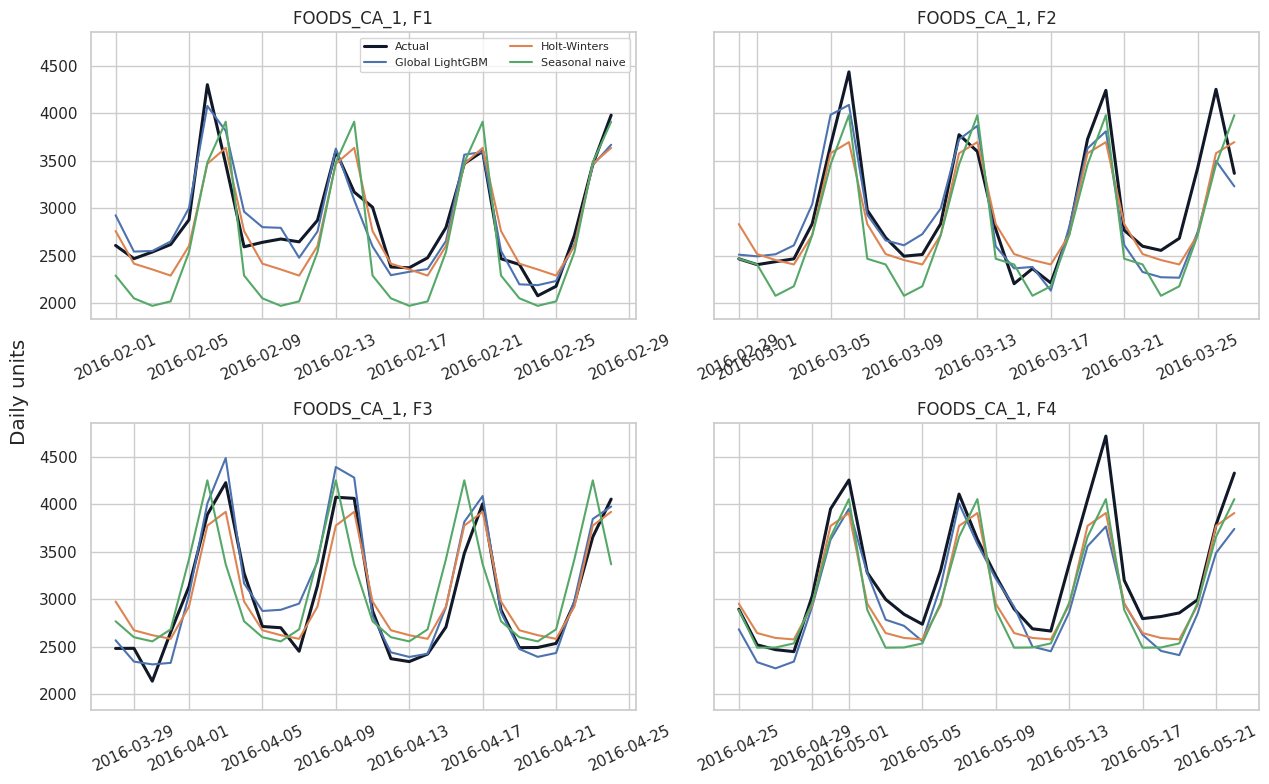

In [14]:
example_series = "FOODS_CA_1"
example_forecasts = all_forecasts.query("series_id == @example_series").copy()
example_forecasts["model_name"] = example_forecasts["model"].map(model_labels)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, fold_id in zip(axes.flat, ["F1", "F2", "F3", "F4"], strict=True):
    subset = example_forecasts.query("fold_id == @fold_id")
    actual = subset.drop_duplicates("forecast_date").sort_values("forecast_date")
    ax.plot(
        actual["forecast_date"],
        actual["actual"],
        color="#111827",
        linewidth=2.2,
        label="Actual",
    )
    for model_name, frame in subset.groupby("model_name", observed=True):
        ax.plot(frame["forecast_date"], frame["forecast"], linewidth=1.5, label=model_name)
    ax.set_title(f"{example_series}, {fold_id}")
    ax.tick_params(axis="x", rotation=25)
axes[0, 0].legend(ncol=2, fontsize=8)
fig.supylabel("Daily units")
fig.tight_layout()
display(fig)
plt.close(fig)


## 10. Summary and limitations

LightGBM achieved the strongest overall performance and passed the pre-specified selection rule. It can support category-store forecast review, model comparison and historical reliability monitoring over a 28-day horizon.

The main limitations are:

1. Holt-Winters was marginally better during days 22–28; recursive error transmission is plausible, but the observed bands do not demonstrate monotonic accumulation;
2. the model generates point forecasts without calibrated prediction intervals;
3. feature gain describes model reliance, not causal influence;
4. future price information is intentionally excluded;
5. the exploratory bootstrap and sign test rely on series-level assumptions and do not establish universal superiority;
6. evidence comes from M5 retail data and may not transfer directly to every organisation.

The model does not produce SKU order quantities, optimise safety stock, recommend supplier actions or explain the causes of demand changes. Notebook 04 uses the selected specification to produce the separate forward forecast.


In [15]:
assert all(path.is_file() for path in handoff_files.values())
print("NOTEBOOK 03 COMPLETED SUCCESSFULLY")


NOTEBOOK 03 COMPLETED SUCCESSFULLY
